# Import libraries

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load full ground truth (unprocessed files)

In [2]:
def load_gt(gt_fname, subset="training"):
    # Read CSV
    df = pd.read_csv(gt_fname)

    # Parse the "actions" column into rows
    rows = []
    for _, row in df.iterrows():
        video_id = row["id"]
        charades_video = row["charades_video"]
        duration = row["length"]
        subset = subset

        # Split multiple actions
        actions = str(row["actions"]).split(";")
        for act in actions:
            if not act.strip():
                continue
            parts = act.split()
            if len(parts) == 3:
                label, start, end = parts
                rows.append({
                    "video_id": video_id,
                    "duration": duration,
                    "subset": subset,
                    "start": float(start),
                    "end": float(end),
                    "label": label,
                    "charades_video": charades_video
                })

    return pd.DataFrame(rows)

## EGO View

In [3]:
ego_df = load_gt("../data/charades/annotations/wise_annotations/CharadesEgo_v1_train_only1st.csv", subset="training")
print("Shape of ego_df:", ego_df.shape)
ego_df.head()

Shape of ego_df: (34256, 7)


,video_id,duration,subset,start,end,label,charades_video
0,D3TR8EGO,31.79,training,3.9,12.0,c156,1K0SU
1,D3TR8EGO,31.79,training,8.2,12.5,c061,1K0SU
2,D3TR8EGO,31.79,training,9.9,18.4,c106,1K0SU
3,D3TR8EGO,31.79,training,12.8,17.9,c067,1K0SU
4,D3TR8EGO,31.79,training,12.2,18.7,c008,1K0SU


# EXO View

In [4]:
exo_df = load_gt("../data/charades/annotations/wise_annotations/CharadesEgo_v1_train_only3rd.csv", subset="training")
print("Shape of exo_df:", exo_df.shape)
exo_df.head()

Shape of exo_df: (34280, 7)


,video_id,duration,subset,start,end,label,charades_video
0,DKF0T,32.42,training,1.9,7.4,c141,38T9C
1,DKF0T,32.42,training,0.0,20.5,c061,38T9C
2,DKF0T,32.42,training,6.4,12.5,c006,38T9C
3,DKF0T,32.42,training,5.5,20.6,c118,38T9C
4,DKF0T,32.42,training,8.9,14.5,c156,38T9C


# Sample the 10 most frequent classes (~ 200 segments for each class) - EXO View only

In [5]:
# Select the 10 most common classes
most_common_classes = sorted(exo_df["label"].value_counts()[:10].index.tolist())
print(most_common_classes)

# Filter the original dataset to include only rows with classes in "most common classes"
most_common_gt = exo_df[exo_df["label"].isin(most_common_classes)].copy()

"""Select training dataset"""
# Sample ~200 rows per label from the filtered dataset
most_common_rows = (
    most_common_gt.groupby("label", group_keys=False)
    .sample(n=200, random_state=42)
    .copy()
)
# Get all unique video_ids from those sampled rows
video_ids_to_include = most_common_rows["video_id"].unique()
# Filter the original df to include all rows with those video_ids
exo_most_common_gt = most_common_gt[
    most_common_gt["video_id"].isin(video_ids_to_include)
].copy()


"""Select testing dataset"""
# Get the rest of most_common_gt
rest_most_common_gt = most_common_gt[
    ~most_common_gt["video_id"].isin(video_ids_to_include)
].copy()
# Sample ~200 rows per label from the filtered dataset
most_common_rows_testing = (
    rest_most_common_gt.groupby("label", group_keys=False)
    .sample(n=150, random_state=42)
    .copy()
)
# Get all unique video_ids from those sampled rows
video_ids_to_include_testing = most_common_rows_testing["video_id"].unique()
# Filter the original df to include all rows with those video_ids
exo_most_common_gt_testing = rest_most_common_gt[
    rest_most_common_gt["video_id"].isin(video_ids_to_include_testing)
].copy()

['c009', 'c059', 'c061', 'c097', 'c106', 'c107', 'c151', 'c152', 'c154', 'c156']


In [6]:
print("Shape of exo_most_common_gt - training subset:", exo_most_common_gt.shape)
exo_most_common_gt.head(10)
print("Shape of exo_most_common_gt_testing - testing subset:", exo_most_common_gt_testing.shape)
exo_most_common_gt_testing.head(10)

Shape of exo_most_common_gt - training subset: (4901, 7)
Shape of exo_most_common_gt_testing - testing subset: (2182, 7)


,video_id,duration,subset,start,end,label,charades_video
1,DKF0T,32.42,training,0.0,20.50,c061,38T9C
4,DKF0T,32.42,training,8.9,14.50,c156,38T9C
115,8Y665,43.33,training,39.0,43.33,c097,NaN
156,BXD6B,29.50,training,23.0,28.50,c009,NaN
157,BXD6B,29.50,training,8.2,27.90,c107,NaN
229,VMXAX,28.38,training,14.3,21.00,c151,NaN
238,RDD9Z,30.00,training,7.2,17.30,c061,MWAGL
239,RDD9Z,30.00,training,8.7,19.30,c154,MWAGL
255,IPZIV,31.04,training,0.0,31.04,c059,H9U38
259,IPZIV,31.04,training,7.5,11.90,c059,H9U38


<Axes: xlabel='label'>

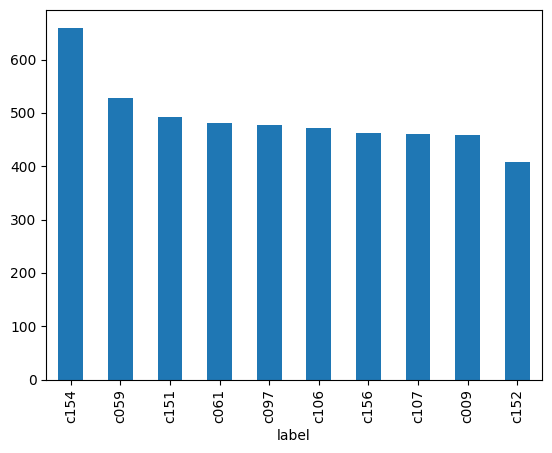

In [7]:
exo_most_common_gt['label'].value_counts().plot(kind='bar')

<Axes: xlabel='label'>

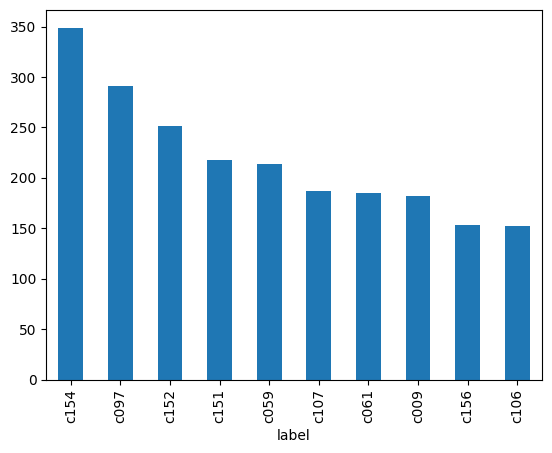

In [8]:
exo_most_common_gt_testing['label'].value_counts().plot(kind='bar')

# Derive ego_most_common_gt

In [9]:
ego_most_common_gt = ego_df[ego_df["video_id"].str[:-3].isin(video_ids_to_include) & ego_df["label"].isin(most_common_classes)].copy()

print("Shape of ego_most_common_gt:", ego_most_common_gt.shape)
ego_most_common_gt[ego_most_common_gt['video_id'] == "WNBBVEGO"]

Shape of ego_most_common_gt: (4887, 7)


,video_id,duration,subset,start,end,label,charades_video
17529,WNBBVEGO,30.71,training,17.2,24.00,c154,TJKGJ
17530,WNBBVEGO,30.71,training,27.7,30.58,c106,TJKGJ
17532,WNBBVEGO,30.71,training,19.8,28.10,c059,TJKGJ
17534,WNBBVEGO,30.71,training,19.5,30.58,c106,TJKGJ
17535,WNBBVEGO,30.71,training,18.0,30.58,c107,TJKGJ
17538,WNBBVEGO,30.71,training,21.5,28.40,c151,TJKGJ
17541,WNBBVEGO,30.71,training,27.7,30.58,c154,TJKGJ
17546,WNBBVEGO,30.71,training,20.1,25.10,c106,TJKGJ


<Axes: xlabel='label'>

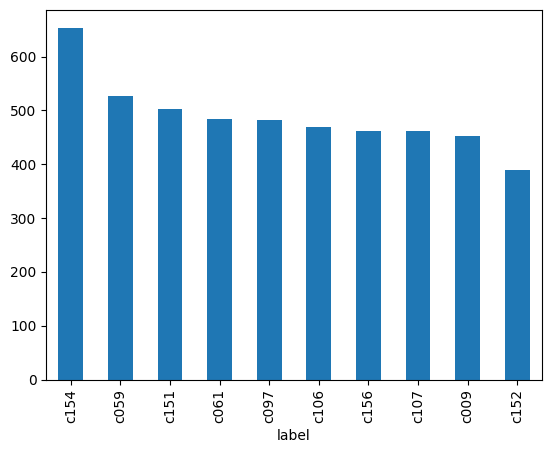

In [10]:
ego_most_common_gt['label'].value_counts().plot(kind='bar')

### Testing subset for ego

In [11]:
ego_most_common_gt_testing = ego_df[ego_df["video_id"].str[:-3].isin(video_ids_to_include_testing) & ego_df["label"].isin(most_common_classes)].copy()

print("Shape of ego_most_common_gt_testing:", ego_most_common_gt_testing.shape)

Shape of ego_most_common_gt_testing: (2191, 7)


<Axes: xlabel='label'>

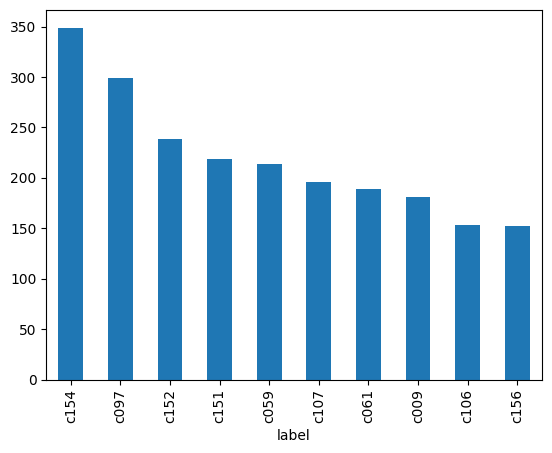

In [12]:
ego_most_common_gt_testing['label'].value_counts().plot(kind='bar')

# Start building dataset

In [13]:
def build_wise_exo_ego_dataset(
    sample_gt_df,
    category_idx_fname="../data/charades/annotations/wise_annotations/sample_category_idx.txt",
    gt_fname="../data/charades/annotations/wise_annotations/sample_charades.json",
    subset="training"
):
    # Save category index to a text file
    actions = sorted(sample_gt_df["label"].unique().tolist())
    with open(category_idx_fname, "w") as f:
        for action in actions:
            f.write(action + "\n")

    # Save sample annotations to JSON file
    output = {"version": "Wise_Exo_Ego", "database": {}}

    for video_id, group in sample_gt_df.groupby("video_id"):
        # keep duration/subset from the original gt
        duration = sample_gt_df[sample_gt_df["video_id"] == video_id]["duration"].iloc[0]
        subset = subset

        annotations = []
        for _, row in group.iterrows():
            annotations.append(
                {"segment": [row["start"], row["end"]], "label": row["label"]}
            )

        output["database"][video_id] = {
            "duration": duration,
            "subset": subset,
            "annotations": annotations,
        }


    with open(gt_fname, "w") as f:
        json.dump(output, f, indent=2)

### For Exo view

In [14]:
build_wise_exo_ego_dataset(
    exo_most_common_gt,
    category_idx_fname="../data/charades/annotations/wise_annotations/exo_only_training_category_idx.txt",
    gt_fname="../data/charades/annotations/wise_annotations/exo_only_training_charades.json",
    subset="training"
)

### For Exo view (testing subset)

In [15]:
build_wise_exo_ego_dataset(
    exo_most_common_gt_testing,
    category_idx_fname="../data/charades/annotations/wise_annotations/exo_only_testing_category_idx.txt",
    gt_fname="../data/charades/annotations/wise_annotations/exo_only_testing_charades.json",
    subset="testing"
)

### For Ego view

In [16]:
build_wise_exo_ego_dataset(
    ego_most_common_gt,
    category_idx_fname="../data/charades/annotations/wise_annotations/ego_only_training_category_idx.txt",
    gt_fname="../data/charades/annotations/wise_annotations/ego_only_training_charades.json",
    subset="training"
)

### For Ego view (testing subset)

In [17]:
build_wise_exo_ego_dataset(
    ego_most_common_gt_testing,
    category_idx_fname="../data/charades/annotations/wise_annotations/ego_only_testing_category_idx.txt",
    gt_fname="../data/charades/annotations/wise_annotations/ego_only_testing_charades.json",
    subset="testing"
)

### For both views

In [18]:
build_wise_exo_ego_dataset(
    pd.concat([exo_most_common_gt, ego_most_common_gt], axis=0, ignore_index=True),
    category_idx_fname="../data/charades/annotations/wise_annotations/combined_training_category_idx.txt",
    gt_fname="../data/charades/annotations/wise_annotations/combined_training_charades.json",
    subset="training"
)

### For both views (testing subset)

In [19]:
build_wise_exo_ego_dataset(
    pd.concat([exo_most_common_gt_testing, ego_most_common_gt_testing], axis=0, ignore_index=True),
    category_idx_fname="../data/charades/annotations/wise_annotations/combined_testing_category_idx.txt",
    gt_fname="../data/charades/annotations/wise_annotations/combined_testing_charades.json",
    subset="testing"
)

### Shape of the combined training dataset

In [20]:
pd.concat([exo_most_common_gt, ego_most_common_gt]).shape

(9788, 7)

### Shape of the combined testing dataset

In [21]:
pd.concat([exo_most_common_gt_testing, ego_most_common_gt_testing]).shape

(4373, 7)

### Number of videos

In [22]:
pd.concat([exo_most_common_gt, ego_most_common_gt])['video_id'].nunique()

2775

### Number of videos (testing subset)

In [23]:
pd.concat([exo_most_common_gt_testing, ego_most_common_gt_testing])['video_id'].nunique()

1812

# ANALYSIS

## Plot exo-ego to view misalignment

In [24]:
exo_most_common_gt.head()

,video_id,duration,subset,start,end,label,charades_video
13,WNBBV,30.58,training,0.0,8.70,c154,TJKGJ
16,WNBBV,30.58,training,20.0,28.20,c059,TJKGJ
18,WNBBV,30.58,training,16.5,30.58,c106,TJKGJ
19,WNBBV,30.58,training,14.5,30.58,c107,TJKGJ
22,WNBBV,30.58,training,18.8,25.10,c151,TJKGJ


In [25]:
ego_most_common_gt.head()

,video_id,duration,subset,start,end,label,charades_video
0,D3TR8EGO,31.79,training,3.9,12.00,c156,1K0SU
1,D3TR8EGO,31.79,training,8.2,12.50,c061,1K0SU
2,D3TR8EGO,31.79,training,9.9,18.40,c106,1K0SU
8,D3TR8EGO,31.79,training,3.9,31.25,c156,1K0SU
9,D3TR8EGO,31.79,training,1.0,31.25,c107,1K0SU


In [27]:
def plot_ego_vs_exo(ego_df, exo_df, video_id, confidence_threshold=0.04):
    ego_video = ego_df[(ego_df["video_id"] == video_id + "EGO")]
    exo_video = exo_df[(exo_df["video_id"] == video_id)]

    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    for _, row in ego_video.iterrows():
        ax[0].plot([row["start"], row["end"]], [row["label"]] * 2)
    ax[0].set_title("Ego Ground Truth")

    for _, row in exo_video.iterrows():
        ax[1].plot([row["start"], row["end"]], [row["label"]] * 2)
    ax[1].set_title("Exo Ground Truth")

    plt.xlabel("Second")
    plt.tight_layout()
    plt.show()

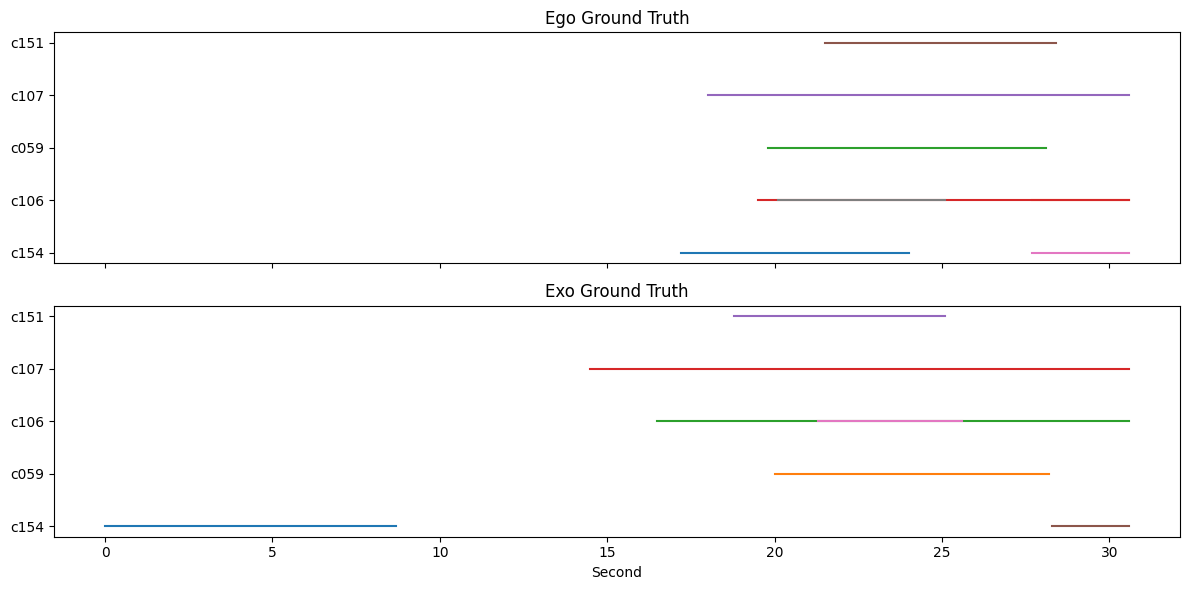

In [28]:
plot_ego_vs_exo(ego_most_common_gt, exo_most_common_gt, video_id="WNBBV")

In [30]:
ego_most_common_gt[ego_most_common_gt["video_id"] == "WNBBVEGO"]

,video_id,duration,subset,start,end,label,charades_video
17529,WNBBVEGO,30.71,training,17.2,24.00,c154,TJKGJ
17530,WNBBVEGO,30.71,training,27.7,30.58,c106,TJKGJ
17532,WNBBVEGO,30.71,training,19.8,28.10,c059,TJKGJ
17534,WNBBVEGO,30.71,training,19.5,30.58,c106,TJKGJ
17535,WNBBVEGO,30.71,training,18.0,30.58,c107,TJKGJ
17538,WNBBVEGO,30.71,training,21.5,28.40,c151,TJKGJ
17541,WNBBVEGO,30.71,training,27.7,30.58,c154,TJKGJ
17546,WNBBVEGO,30.71,training,20.1,25.10,c106,TJKGJ


In [31]:
exo_most_common_gt[exo_most_common_gt["video_id"] == "WNBBV"]

,video_id,duration,subset,start,end,label,charades_video
13,WNBBV,30.58,training,0.0,8.70,c154,TJKGJ
16,WNBBV,30.58,training,20.0,28.20,c059,TJKGJ
18,WNBBV,30.58,training,16.5,30.58,c106,TJKGJ
19,WNBBV,30.58,training,14.5,30.58,c107,TJKGJ
22,WNBBV,30.58,training,18.8,25.10,c151,TJKGJ
25,WNBBV,30.58,training,28.3,30.58,c154,TJKGJ
30,WNBBV,30.58,training,21.3,25.60,c106,TJKGJ


## Classes Distribution

In [42]:
exo_df['label'].value_counts()[:20]

label
c154    1163
c097     911
c059     772
c151     755
c152     752
c061     688
c009     657
c107     657
c106     626
c156     616
c118     507
c110     486
c063     478
c008     442
c109     441
c062     433
c001     430
c015     428
c011     424
c149     417
Name: count, dtype: int64

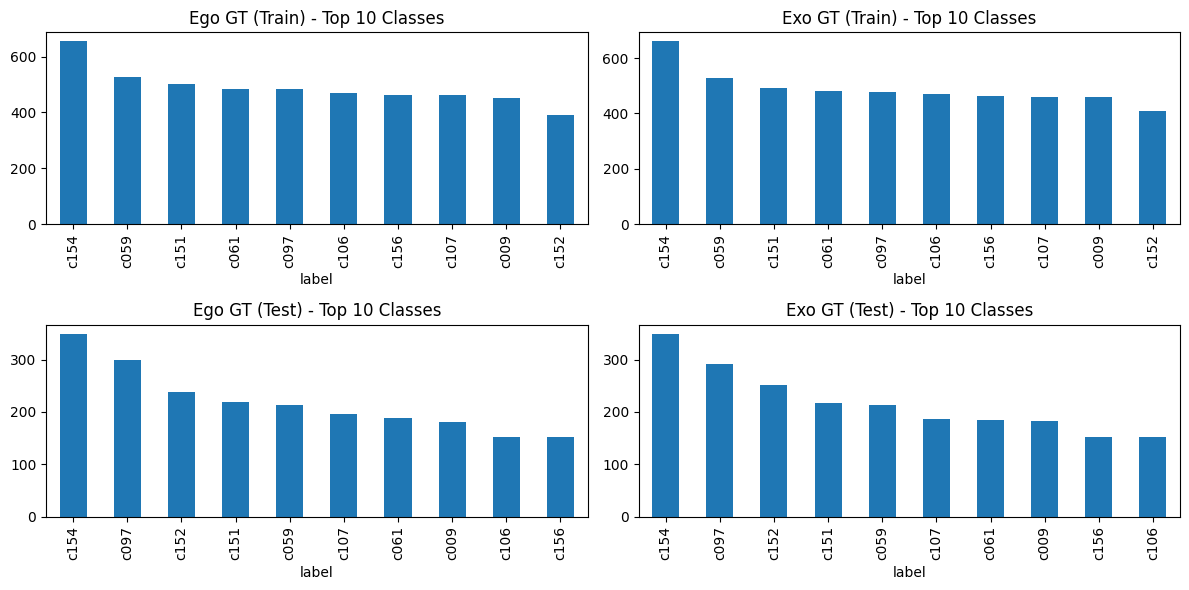

In [55]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))

ego_most_common_gt['label'].value_counts().plot(kind='bar', ax=ax[0, 0])
exo_most_common_gt['label'].value_counts().plot(kind='bar', ax=ax[0, 1])
ego_most_common_gt_testing['label'].value_counts().plot(kind='bar', ax=ax[1, 0])
exo_most_common_gt_testing['label'].value_counts().plot(kind='bar', ax=ax[1, 1])

ax[0, 0].set_title("Ego GT (Train) - Top 10 Classes")
ax[0, 1].set_title("Exo GT (Train) - Top 10 Classes")
ax[1, 0].set_title("Ego GT (Test) - Top 10 Classes")
ax[1, 1].set_title("Exo GT (Test) - Top 10 Classes")

fig.tight_layout()
plt.show()


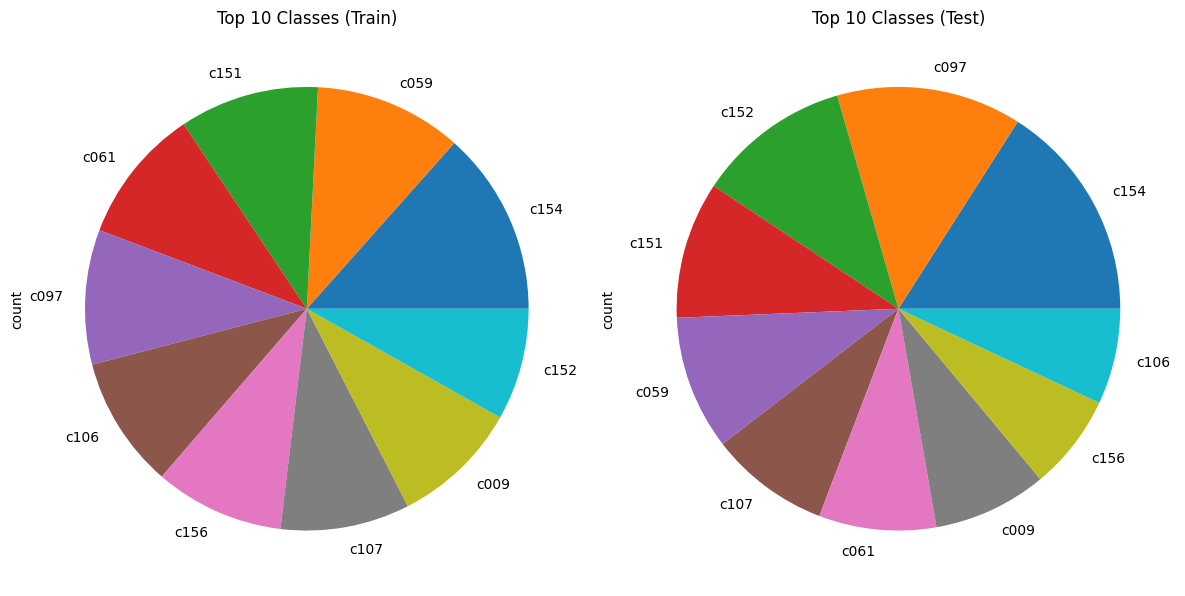

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

pd.concat([exo_most_common_gt, ego_most_common_gt])['label'].value_counts().plot(kind='pie', ax=ax[0])
pd.concat([exo_most_common_gt_testing, ego_most_common_gt_testing])['label'].value_counts().plot(kind='pie', ax=ax[1])

ax[0].set_title("Top 10 Classes (Train)")
ax[1].set_title("Top 10 Classes (Test)")

fig.tight_layout()
plt.show()

In [75]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mAP_curve(mAP_values, title="mAP@[0.1:0.9] for Egocentric Baseline Model", optional_mAP_values=None):
    if len(mAP_values) != 9:
        raise ValueError("mAP_values must contain exactly 9 values (for thresholds 0.1 to 0.9).")

    thresholds = np.arange(0.1, 1.0, 0.1)  # [0.1, 0.2, ..., 0.9]

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, mAP_values, marker='o', linestyle='-', color='b', label="mAP")
    plt.xticks(thresholds)
    plt.xlabel("IoU Threshold")
    plt.ylabel("mAP (%)")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()

    if optional_mAP_values is not None:
        plt.plot(thresholds, optional_mAP_values, marker='x', linestyle='--', color='r', label="Optional mAP")
        plt.legend()

    plt.show()

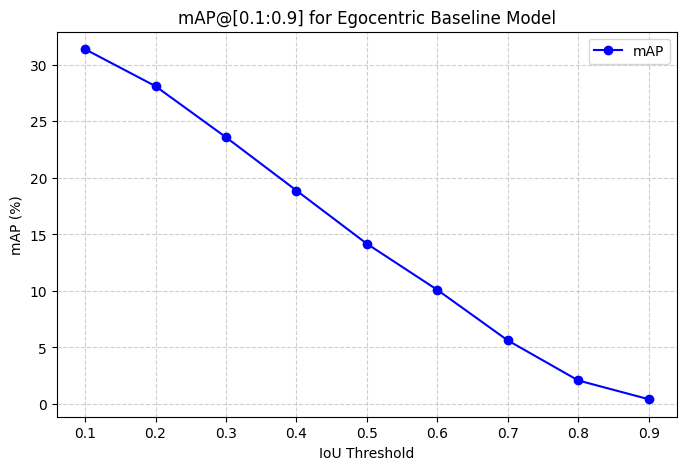

In [74]:
plot_mAP_curve([31.38, 28.11, 23.59, 18.88, 14.17, 10.09, 5.62, 2.08, 0.42])

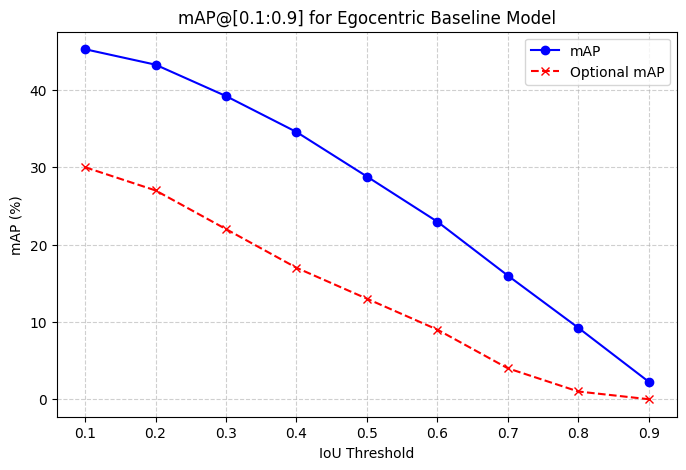

In [76]:
plot_mAP_curve([45.26, 43.26, 39.20, 34.56, 28.80, 22.96, 15.99, 9.24, 2.26], optional_mAP_values=[30.0, 27.0, 22.0, 17.0, 13.0, 9.0, 4.0, 1.0, 0.0])